In [59]:
from typing import Any, Callable

import equinox as eqx
import jax
import jax.numpy as jnp
from spyx.axn import arctan

_spike_fn = arctan(k=2)
class FeLIF(eqx.Module):
    out_size: int = eqx.field(static=True)
    P_s: float = eqx.field(static=True)  # max polarisation
    A: float = eqx.field(static=True)
    C_tot: float = eqx.field(static=True)
    threshold: float = eqx.field(static=True)
    step: Callable[[Any, Any], Any] = eqx.field(static=True)
    cap_divider: float = eqx.field(static=True)
    depol_divider: float = eqx.field(static=True)

    def __init__(
        self,
        out_size,
        A=25e-12,  # device area
        t_hzo=10e-9,  # thikness ferroelectric
        t_int=1.375e-9,  # thikness interlayer
        eps_hzo=25.2,  # ferroelectric dielectric constant
        eps_int=33,  # interlayer dielectric constant
        E_a=12.7e8,  # coercitive field
        P_s=22e-2,  # max polarisation
        tau_0=1e-13,  # multiplicative factor for switching time constant
        I_0=1e-4,  # mult factor for leakage current
        V_t=0.32,  # normalization factor for voltage in leakage current
        C_par=15e-15,  # parasitic capacitance form the circuit
        alpha=1.3,  # to fit tau exponential
        soft_E=5e6,  # soft boudary for the electric field, avoid tau to diverge
        I_dsc=10e-12,  # discharge current, set the "dendritic time constant"
        V_thr=2.5,
        dt=1e-3,  # 1us timestep resolution
        innerStep=1000,
        paramsScale=1e12,  # Scale parameters to avoid underflow
        spike_fn=_spike_fn,
        stepFull=False,
        *,
        key=None
    ):
        _eps0 = 8.85418792394420013968e-12 * paramsScale
        self.out_size = out_size

        A = A * paramsScale
        self.A = A
        t_hzo = t_hzo * paramsScale
        t_int = t_int * paramsScale
        eps_hzo = eps_hzo
        eps_int = eps_int
        E_a = E_a / paramsScale
        P_s = P_s
        tau_0 = tau_0
        I_0 = I_0
        V_t = V_t
        C_par = C_par * paramsScale
        alpha = alpha
        soft_E = soft_E / paramsScale
        I_dsc = I_dsc * paramsScale
        V_thr = V_thr
        dt = dt
        innerStep = innerStep
        paramsScale = paramsScale

        C_0 = _eps0 * eps_hzo / t_hzo * A
        C_tot = C_0 + C_par
        self.C_tot = C_tot

        cap_divider = eps_int / (t_hzo * eps_hzo + t_int * eps_int)
        self.cap_divider = cap_divider
        depol_divider = 1 / _eps0 * t_int / (t_hzo * eps_hzo + t_int * eps_int)
        self.depol_divider = depol_divider
        threshold = V_thr * C_tot + P_s * A
        self.threshold = threshold
        self.P_s = P_s

        def updatePol(v, p):

            def pol_step(state, input_):
                p, I_p = state
                E = v * cap_divider - p * depol_divider
                
                tau = tau_0 * jnp.exp((E_a / (jnp.abs(E) + 5e-6)) ** alpha) # Change soft_E to 5e-5 to avoid inf

                I_p_new = jnp.clip((jnp.sign(E)*P_s - p)*A/tau, 0, 100e6)
                dp = I_p_new / A
                p = jnp.clip(p + 1e-3*dt * dp, -P_s, P_s)
                return (p, I_p_new), None

            (p, I_p), _ = jax.lax.scan(pol_step, (p, jnp.zeros_like(p)), jnp.arange(1000))

            return p, I_p

        def step(state, input_):
            v, p = state

            charge = v * C_tot + p * A
            spikes = spike_fn(charge - threshold)
            
            p_upper, I_p = updatePol(v, p)

            I_leak = (1e-4 * A * jnp.expm1(v / V_t) + I_dsc) * jnp.sign(v)
            dv = (input_ - I_leak - I_p) / C_tot

            v_upper = jnp.clip(v + dt * dv, 0, 5)

            spikes_ref = jax.lax.stop_gradient(spikes)
            v_new = (1 - spikes_ref) * v_upper
            p_new = (1 - spikes_ref) * p_upper - (spikes_ref * P_s)

            return (v_new, p_new), (v_new, p_new, spikes)
        
        def step_full(state, input_):
            v, p = state

            charge = v * C_tot + p * A
            spikes = spike_fn(charge - threshold)

            E = v * self.cap_divider - p * self.depol_divider
            
            tau = tau_0 * jnp.exp((E_a / (jnp.abs(E) + 5e-6)) ** alpha) # Change soft_E to 5e-5 to avoid inf

            I_p = jnp.clip((jnp.sign(E)*self.P_s - p)*A/tau, 0, 100e6)
            dp = I_p / A
            
            I_leak = (1e-4 * A * jnp.expm1(v / V_t) + I_dsc) * jnp.sign(v)
            dv = (input_ - I_leak - I_p) / C_tot
        
            v_upper = jnp.clip(v + dt * dv, 0, 5)
            p_upper = jnp.clip(p + dt * dp, -self.P_s, self.P_s)

            spikes_ref = jax.lax.stop_gradient(spikes)
            v_new = (1 - spikes_ref) * v_upper
            p_new = (1 - spikes_ref) * p_upper - (spikes_ref * P_s)

            return (v_new, p_new), (v_new, p_new, spikes)

        if stepFull:
            self.step = jax.jit(step_full)
        else:
            self.step = jax.jit(step)

    @eqx.filter_jit
    def getCharge(self, v, p):
        return v * self.C_tot + p * self.A

    @jax.named_scope("nn.FeLIF")
    def __call__(self, input_):
        v0 = jnp.zeros((self.out_size,))
        p0 = jnp.zeros((self.out_size,)) - self.P_s

        state = (v0, p0)
        _, out = jax.lax.scan(self.step, state, input_)
        v, p, s = out

        return s, self.getCharge(v, p), v, p

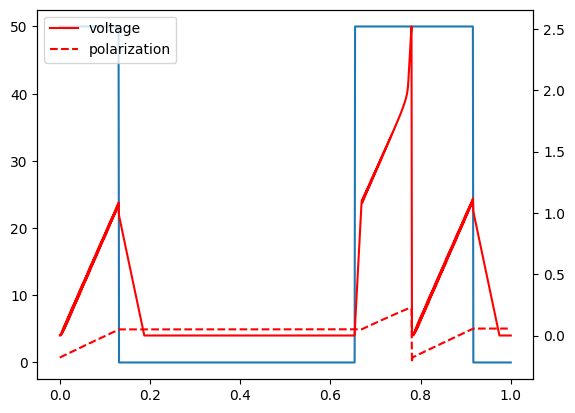

In [60]:
import matplotlib.pyplot as plt

t = jnp.linspace(0, 1, 1000)
input = jnp.cos(8*t)
input = 1.0*50*jnp.sign(input)*(input>0.5)
felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-3, stepFull=False, key=None)
s, c, v, p = felif(input)

plt.figure()
plt.plot(t, input, label='input')
ax=plt.gca().twinx()
ax.plot(t, v, 'r', label='voltage')
ax.plot(t, p, 'r--', label='polarization')
plt.legend()
plt.show()

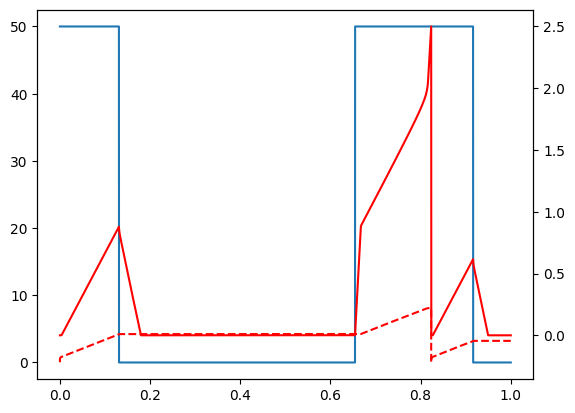

In [62]:
t = jnp.linspace(0, 1, 1000000)
input = jnp.cos(8*t)
input = 1.0*50*jnp.sign(input)*(input>0.5)
felif = FeLIF(1, spike_fn=_spike_fn, dt=1e-6, stepFull=True, key=None)
s, c, v, p = felif(input)

plt.figure()
plt.plot(t, input)
ax=plt.gca().twinx()
ax.plot(t, v, 'r')
ax.plot(t, p, 'r--')
plt.show()